# WEEE — Aktiviteden MET Tahmini (E4, Zephyr, Muse ivmesi)

Üç cihazın ivmesini ayrı ayrı işleyip MET ile korelasyonuna bakıyorum, sonra karşılaştırıyorum. Model yok, önce feature'ların işe yarayıp yaramadığına bakıyorum.

Notlar: E4 (bilek) 32 Hz, ham 1/64 g. Zephyr (göğüs) Accel.csv 100 Hz, ham 3 eksen. Muse (kafa) acc.csv ~44 Hz, zaten g. Zamanlar UTC. Filtre: E4 ve Muse 0.5–12 Hz, Zephyr 0.5–20 Hz. Feature'lar eski projedeki 6 tanesiyle aynı.

### Drive'ı bağla

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Zip'i aç, DATA_ROOT'u ayarla



In [ ]:
import glob, shutil, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import pearsonr, spearmanr, kruskal

zips = glob.glob('/content/drive/MyDrive/PAWS/*.zip')
zip_path = zips[0]
shutil.unpack_archive(zip_path, '/content/weee_data')
hits = glob.glob('/content/weee_data/**/Study_Information.csv', recursive=True)
DATA_ROOT = os.path.dirname(hits[0])
print("DATA_ROOT =", DATA_ROOT)

WIN_SEC=4; OVERLAP=0.5

DATA_ROOT = /content/weee_data/dataset


### Yardımcı fonksiyonlar ve feature'lar

In [ ]:
def bandpass(x,fs,low,high,order=4):
    nyq=fs/2.0; high=min(high,nyq*0.95)
    b,a=butter(order,[low/nyq,high/nyq],btype='bandpass')
    x=pd.Series(x,dtype='float64').interpolate(limit_direction='both').to_numpy()
    return filtfilt(b,a,np.nan_to_num(x))

def mag3(x,y,z): return np.sqrt(x**2+y**2+z**2)

def segment_signal(sig, fs, win_sec=WIN_SEC, overlap=OVERLAP):
    sig=np.asarray(sig); w=int(round(win_sec*fs)); step=max(1,int(round(w*(1-overlap))))
    return [sig[s:s+w] for s in range(0,len(sig)-w+1,step)]

FEATURE_NAMES=["energy","shannon_entropy","max_amplitude","max_location","min_amplitude","min_location"]
def shannon_entropy(w,bins=32):
    h,_=np.histogram(w,bins=bins); p=h.astype(float); p=p[p>0]
    if p.size==0: return 0.0
    p/=p.sum(); return float(-np.sum(p*np.log2(p)))
def feats6(w):
    w=np.asarray(w,float)
    return [float(np.sum(w**2)),shannon_entropy(w),float(w.max()),int(w.argmax()),float(w.min()),int(w.argmin())]

EE_NAMES=["enmo","std","rms","sma","dom_freq","spec_entropy"]
def feats_ee(wbp,wraw,fs):
    wbp=np.asarray(wbp,float); wraw=np.asarray(wraw,float)
    enmo=float(np.mean(np.maximum(wraw-1.0,0.0)))
    spec=np.abs(np.fft.rfft(wbp)); fr=np.fft.rfftfreq(len(wbp),1/fs)
    dom=float(fr[1:][np.argmax(spec[1:])]) if len(spec)>1 else 0.0
    p=spec**2; p=p/(p.sum()+1e-12)
    return [enmo,float(wbp.std()),float(np.sqrt(np.mean(wbp**2))),float(np.mean(np.abs(wbp))),dom,float(-np.sum(p*np.log2(p+1e-12)))]

def corr_table(d,cols):
    bonf=0.05/len(cols); out=[]
    for c in cols:
        rp,pp=pearsonr(d[c],d['MET']); rs,ps=spearmanr(d[c],d['MET'])
        out.append(dict(feature=c,pearson=round(rp,3),spearman=round(rs,3),p_spearman=f"{ps:.1e}",
                        sig='***' if ps<bonf else '*' if ps<0.05 else ''))
    return pd.DataFrame(out).sort_values('spearman',key=lambda s:s.abs(),ascending=False).reset_index(drop=True)
print("hazır")

hazır


### Study_Information → aktivite aralıkları ve MET

In [ ]:
ACTS=[('Sit','Start_Sit','MET_Sit'),('Stand','Start_Stand','MET_Stand'),
      ('Cycle1','Start_Cycle1','MET_Cycle1'),('Cycle2','Start_Cycle2','MET_Cycle2'),
      ('Run1','Start_Run1','MET_Run1'),('Run2','Start_Run2','MET_Run2')]
def to_unix(s): return pd.Timestamp(str(s).strip()).tz_localize('UTC').timestamp()
def to_num(x):
    try: return float(str(x).strip())
    except: return np.nan
def activity_segments(r):
    starts=[to_unix(r[c]) for _,c,_ in ACTS]; out=[]
    for i,(name,sc,mc) in enumerate(ACTS):
        st=starts[i]; nxt=starts[i+1] if i+1<len(starts) else st+300; en=min(nxt,st+300)
        out.append(dict(activity=name,MET=to_num(r[mc]),start=st,end=en,valid=en>st))
    return out
SI=pd.read_csv(os.path.join(DATA_ROOT,'Study_Information.csv'))
print(SI['Participant'].tolist())

['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17']


### Cihaz okuyucular ve feature tablosu kurma

In [ ]:
def load_device(path, kind):
    if kind=='E4':
        raw=pd.read_csv(path,header=None); t0=float(raw.iloc[0,0]); fs=float(raw.iloc[1,0])
        d=raw.iloc[2:].reset_index(drop=True).astype(float)/64.0
        x,y,z=d.iloc[:,0].values,d.iloc[:,1].values,d.iloc[:,2].values
        return x,y,z,fs,t0+np.arange(len(x))/fs
    elif kind=='ZEPHYR':
        z=pd.read_csv(path)
        tt=pd.to_datetime(z['Time'],format='%d/%m/%Y %H:%M:%S.%f').dt.tz_localize('UTC').map(lambda x:x.timestamp()).values
        return z['Vertical'].values,z['Lateral'].values,z['Sagittal'].values,100.0,tt
    else:  # MUSE
        d=pd.read_csv(path,header=None); d.columns=['t','x','y','z']
        d=d.sort_values('t').reset_index(drop=True)     # Muse zaman damgaları düzensiz
        tt=d['t'].values; fs=len(d)/(tt[-1]-tt[0])       # efektif fs (~44 Hz)
        return d['x'].values,d['y'].values,d['z'].values,fs,tt

DEV = {'E4':    dict(pat='*/E4/ACC.csv',        band=(0.5,12.0), ee=True),
       'ZEPHYR':dict(pat='*/ZEPHYR/*_Accel.csv',band=(0.5,20.0), ee=False),
       'MUSE':  dict(pat='*/MUSE/acc.csv',      band=(0.5,12.0), ee=False)}

def build_table(kind):
    cfg=DEV[kind]; low,high=cfg['band']; rows=[]; qc=[]
    for path in sorted(glob.glob(os.path.join(DATA_ROOT,cfg['pat']))):
        folder=path.split(os.sep)[-3]
        pid='P%02d'%int(''.join(filter(str.isdigit,folder)))
        r=SI[SI['Participant']==pid]
        if len(r)==0: qc.append((pid,'-','SI yok',0)); continue
        try:
            x,y,z,fs,tt=load_device(path,kind)
            mbp=mag3(bandpass(x,fs,low,high),bandpass(y,fs,low,high),bandpass(z,fs,low,high))
            mraw=mag3(x,y,z) if cfg['ee'] else None
            for s in activity_segments(r.iloc[0]):
                if not s['valid']: qc.append((pid,s['activity'],'geçersiz zaman',0)); continue
                m=(tt>=s['start'])&(tt<s['end'])
                wb=segment_signal(mbp[m],fs)
                wr=segment_signal(mraw[m],fs) if cfg['ee'] else [None]*len(wb)
                qc.append((pid,s['activity'],'ok' if len(wb) else 'kapsamıyor',len(wb)))
                for a1,a2 in zip(wb,wr):
                    row=dict(zip(FEATURE_NAMES,feats6(a1)))
                    if cfg['ee']: row.update(dict(zip(EE_NAMES,feats_ee(a1,a2,fs))))
                    row.update(MET=s['MET'],activity=s['activity'],subject=pid); rows.append(row)
        except Exception as e:
            qc.append((pid,'-',f'hata:{e}',0))
    return pd.DataFrame(rows),pd.DataFrame(qc,columns=['subject','activity','status','n_windows'])
print("hazır")

hazır


## E4 (bilek)

### Örnekleme hızları (P01)

In [ ]:
pid='P01'; e4dir=None
for c in [pid,'P%d'%int(pid[1:])]:
    d=os.path.join(DATA_ROOT,c,'E4')
    if os.path.isdir(d): e4dir=d; break
print(f"{'sinyal':<10}{'fs (Hz)':>8}")
for f in sorted(glob.glob(os.path.join(e4dir,'*.csv'))):
    try:
        raw=pd.read_csv(f,header=None); print(f"{os.path.basename(f):<10}{float(raw.iloc[1,0]):>8.0f}")
    except Exception: print(os.path.basename(f),"okunamadı")

sinyal     fs (Hz)
ACC.csv         32
BVP.csv         64
EDA.csv          4
HR.csv           1
IBI.csv         17
TEMP.csv         4
tags.csv okunamadı


### P01 aktivite bazında sinyal

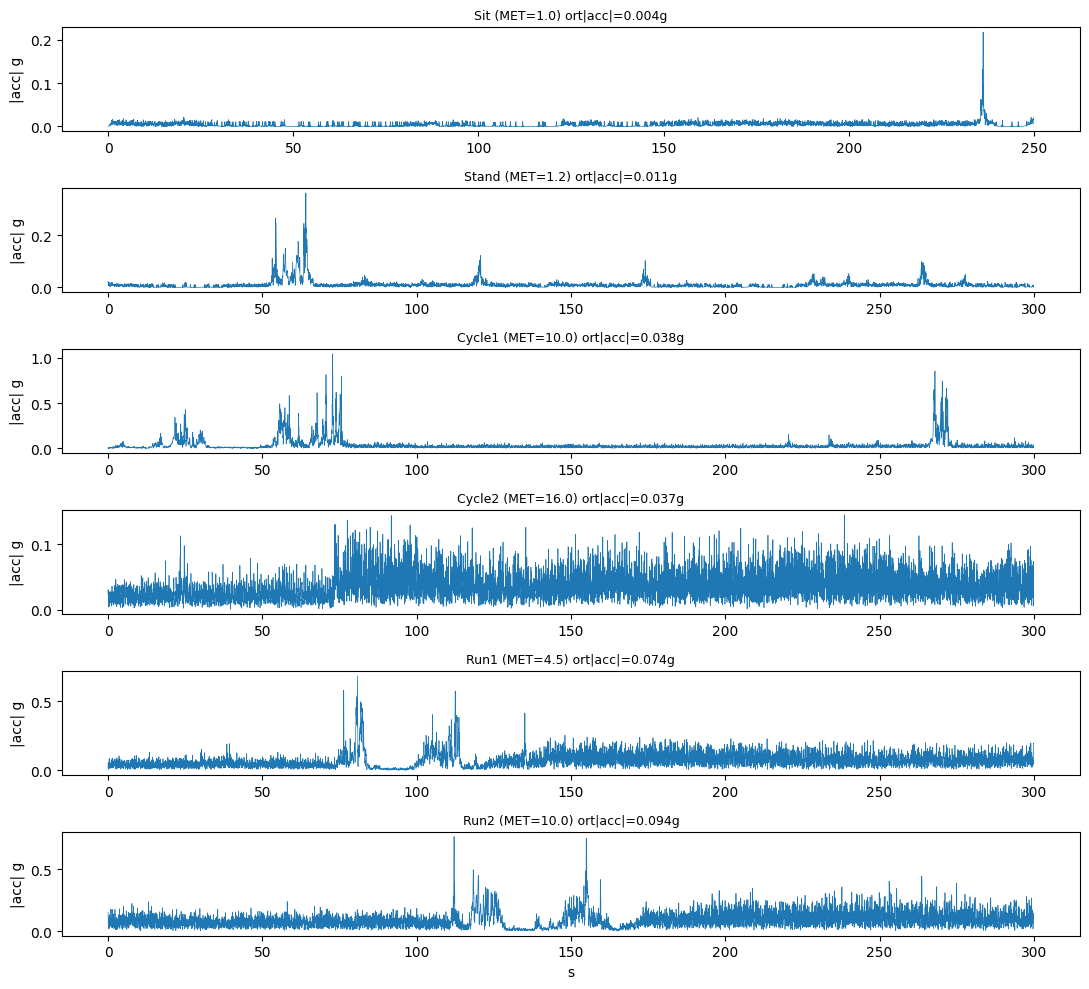

In [ ]:
x,y,z,fs,tt=load_device(os.path.join(e4dir,'ACC.csv'),'E4')
mbp=mag3(bandpass(x,fs,0.5,12),bandpass(y,fs,0.5,12),bandpass(z,fs,0.5,12))
seg0=activity_segments(SI[SI['Participant']=='P01'].iloc[0])
fig,axs=plt.subplots(len(seg0),1,figsize=(11,10))
for ax,s in zip(axs,seg0):
    m=(tt>=s['start'])&(tt<s['end']); sig=mbp[m]
    ax.plot(np.arange(len(sig))/fs,sig,lw=0.5)
    ax.set_title(f"{s['activity']} (MET={s['MET']}) ort|acc|={sig.mean():.3f}g",fontsize=9); ax.set_ylabel('|acc| g')
axs[-1].set_xlabel('s'); plt.tight_layout(); plt.show()

### E4 feature tablosu
Not: P14'ün bisiklet/koşu saatleri hatalı girilmiş, atlanıyor. P10'da E4 geç başladığı için sit/stand yok.

In [ ]:
df,qc4=build_table('E4')
print("tablo:",df.shape,"| özne:",df['subject'].nunique())
df.to_csv('weee_e4_features.csv',index=False)
print(qc4[qc4['status']!='ok'].to_string(index=False) if (qc4['status']!='ok').any() else "sorunlu segment yok")

tablo: (13910, 15) | özne: 17
subject activity         status  n_windows
    P10      Sit     kapsamıyor          0
    P10    Stand     kapsamıyor          0
    P14    Stand geçersiz zaman          0
    P14   Cycle1 geçersiz zaman          0
    P14   Cycle2 geçersiz zaman          0
    P14     Run1 geçersiz zaman          0
    P14     Run2     kapsamıyor          0


### E4 feature ↔ MET korelasyonu

In [ ]:
corr_e4=corr_table(df,FEATURE_NAMES); print(corr_e4.to_string(index=False))

        feature  pearson  spearman p_spearman sig
  min_amplitude    0.379     0.637    0.0e+00 ***
         energy    0.384     0.628    0.0e+00 ***
  max_amplitude    0.466     0.614    0.0e+00 ***
shannon_entropy    0.212     0.158    6.5e-79 ***
   max_location    0.018     0.019    2.5e-02   *
   min_location    0.006     0.006    4.5e-01    


Not: window sayısı çok ve pencereler bağımsız olmadığı için buradaki p-değerleri çok küçük çıkıyor. Gerçek anlamlılık için segment bazlı korelasyona bakmak daha doğru.

### E4 feature MET'i takip ediyor mu

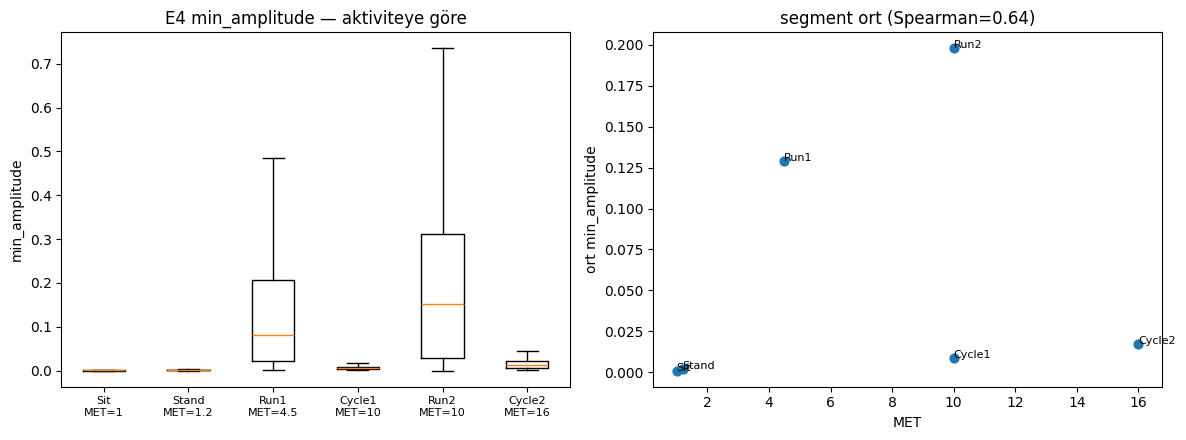

In [ ]:
top=corr_e4['feature'].iloc[0]
order=df.groupby('activity')['MET'].first().sort_values().index.tolist()
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].boxplot([df[df.activity==o][top] for o in order], showfliers=False)
ax[0].set_xticks(range(1,len(order)+1))
ax[0].set_xticklabels([f"{o}\nMET={df[df.activity==o]['MET'].iloc[0]:g}" for o in order], fontsize=8)
ax[0].set_ylabel(top); ax[0].set_title(f"E4 {top} — aktiviteye göre")
agg=df.groupby('activity').agg(MET=('MET','first'),f=(top,'mean')).reset_index()
ax[1].scatter(agg['MET'],agg['f'],s=40)
for _,rr in agg.iterrows(): ax[1].annotate(rr['activity'],(rr['MET'],rr['f']),fontsize=8)
ax[1].set_xlabel('MET'); ax[1].set_ylabel(f'ort {top}'); ax[1].set_title(f"segment ort (Spearman={spearmanr(df[top],df['MET'])[0]:.2f})")
plt.tight_layout(); plt.show()

### E4 EE feature'ları (ENMO dahil)

In [ ]:
print(corr_table(df,EE_NAMES).to_string(index=False))

     feature  pearson  spearman p_spearman sig
         sma    0.438     0.634    0.0e+00 ***
         rms    0.443     0.628    0.0e+00 ***
         std    0.457     0.610    0.0e+00 ***
        enmo    0.405     0.600    0.0e+00 ***
spec_entropy   -0.461    -0.433    0.0e+00 ***
    dom_freq    0.235     0.419    0.0e+00 ***


### E4 segment bazlı korelasyon
Her aktivite bloğu tek MET değerine sahip, o yüzden özne×aktivite ortalaması alıp korele ediyorum.

In [ ]:
agg_e4=df.groupby(['subject','activity']).agg({**{c:'mean' for c in FEATURE_NAMES+EE_NAMES},'MET':'first'}).reset_index()
print("segment:",len(agg_e4)); print(corr_table(agg_e4,['enmo','energy','rms','min_amplitude','sma','std']).to_string(index=False))

segment: 95
      feature  pearson  spearman p_spearman sig
min_amplitude    0.432     0.664    2.3e-13 ***
          sma    0.468     0.661    3.2e-13 ***
          rms    0.472     0.657    5.0e-13 ***
          std    0.494     0.628    9.6e-12 ***
         enmo    0.438     0.608    6.4e-11 ***
       energy    0.417     0.599    1.4e-10 ***


### E4 Kruskal-Wallis
Not: p-değerleri yine çok küçük (aynı bağımsızlık durumu).

In [ ]:
print(f"{'feature':<16}{'H':>10}{'p':>12}   ayrışıyor?")
for c in FEATURE_NAMES+EE_NAMES:
    H,p=kruskal(*[g[c].values for _,g in df.groupby('activity')])
    print(f"{c:<16}{H:>10.1f}{p:>12.1e}   {'evet' if p<0.05 else 'hayir'}")

feature                  H           p   ayrışıyor?
energy             10712.1     0.0e+00   evet
shannon_entropy     1044.4    1.5e-223   evet
max_amplitude      10433.1     0.0e+00   evet
max_location           5.7     3.3e-01   hayir
min_amplitude      10512.7     0.0e+00   evet
min_location           0.9     9.7e-01   hayir
enmo               10079.9     0.0e+00   evet
std                10438.6     0.0e+00   evet
rms                10712.1     0.0e+00   evet
sma                10806.4     0.0e+00   evet
dom_freq            3740.6     0.0e+00   evet
spec_entropy        4832.8     0.0e+00   evet


## Zephyr (göğüs)
Ham 3 eksen Accel.csv (100 Hz), filtre 0.5–20 Hz (Nyquist 50).

### Zephyr feature tablosu

In [ ]:
zdf,qcz=build_table('ZEPHYR')
print("tablo:",zdf.shape,"| özne:",zdf['subject'].nunique())
zdf.to_csv('weee_zephyr_features.csv',index=False)
print(qcz[qcz['status']!='ok'].to_string(index=False) if (qcz['status']!='ok').any() else "sorunlu segment yok")

tablo: (13902, 9) | özne: 17
subject activity         status  n_windows
    P10      Sit     kapsamıyor          0
    P10    Stand     kapsamıyor          0
    P14    Stand geçersiz zaman          0
    P14   Cycle1 geçersiz zaman          0
    P14   Cycle2 geçersiz zaman          0
    P14     Run1 geçersiz zaman          0
    P14     Run2     kapsamıyor          0


### P01 Zephyr aktivite bazında sinyal

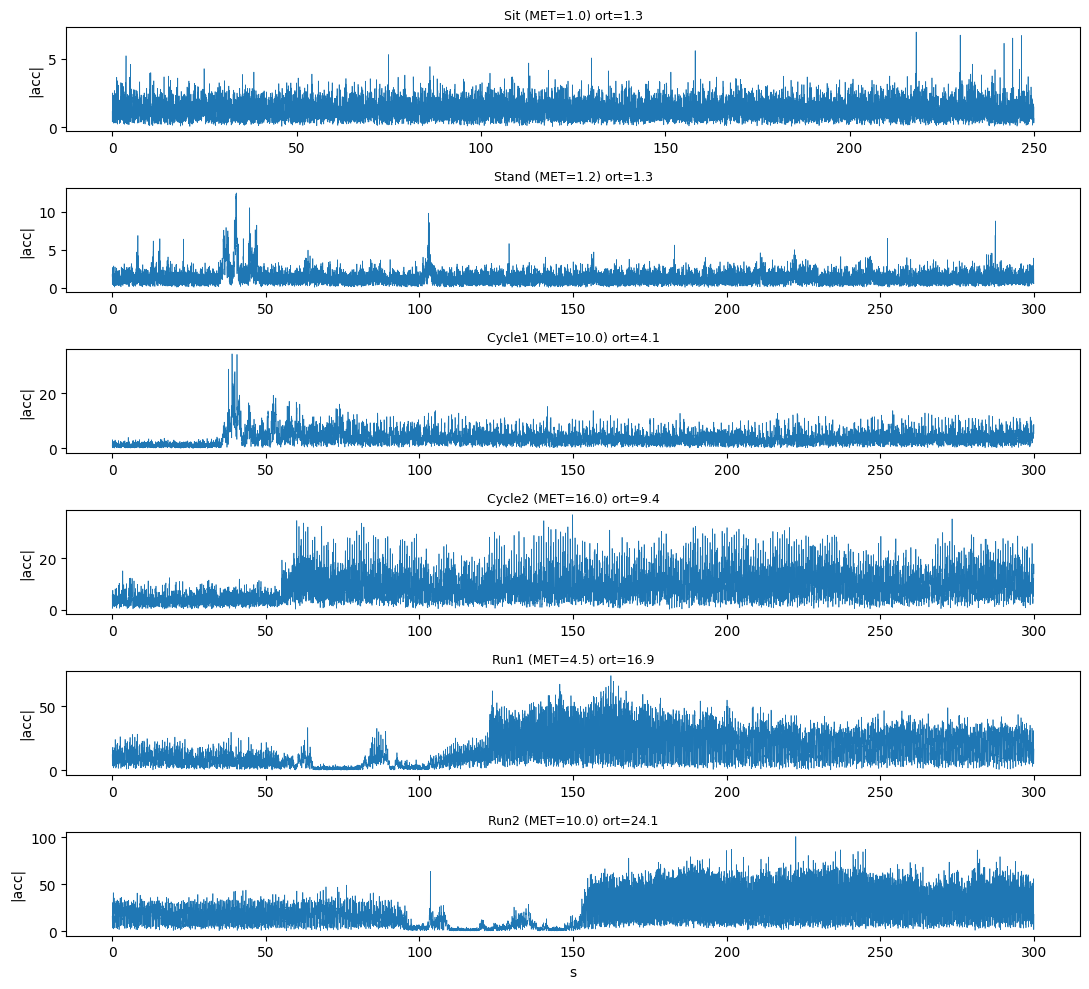

In [ ]:
zx,zy,zz,zfs,ztt=load_device(glob.glob(os.path.join(DATA_ROOT,'P01','ZEPHYR','*_Accel.csv'))[0],'ZEPHYR')
zmbp=mag3(bandpass(zx,zfs,0.5,20),bandpass(zy,zfs,0.5,20),bandpass(zz,zfs,0.5,20))
fig,axs=plt.subplots(len(seg0),1,figsize=(11,10))
for ax,s in zip(axs,seg0):
    m=(ztt>=s['start'])&(ztt<s['end']); sig=zmbp[m]
    ax.plot(np.arange(len(sig))/zfs,sig,lw=0.5)
    ax.set_title(f"{s['activity']} (MET={s['MET']}) ort={sig.mean():.1f}",fontsize=9); ax.set_ylabel('|acc|')
axs[-1].set_xlabel('s'); plt.tight_layout(); plt.show()

### Zephyr feature ↔ MET korelasyonu

In [ ]:
corr_z=corr_table(zdf,FEATURE_NAMES); print(corr_z.to_string(index=False))

        feature  pearson  spearman p_spearman sig
         energy    0.396     0.686    0.0e+00 ***
  max_amplitude    0.460     0.678    0.0e+00 ***
  min_amplitude    0.490     0.667    0.0e+00 ***
shannon_entropy    0.241     0.297   2.5e-280 ***
   max_location   -0.013    -0.013    1.2e-01    
   min_location    0.006     0.008    3.7e-01    


## Karşılaştırma: E4 (bilek) vs Zephyr (göğüs)
Aynı 6 feature, aynı pipeline. Hangi konum MET'i daha iyi yakalıyor.

In [ ]:
def sp_map(d): return {c:round(spearmanr(d[c],d['MET'])[0],3) for c in FEATURE_NAMES}
def seglev(d): return d.groupby(['subject','activity']).agg({**{c:'mean' for c in FEATURE_NAMES},'MET':'first'}).reset_index()
PAIR={'E4_bilek':df,'Zephyr_gogus':zdf}
cw=pd.DataFrame({n:sp_map(d) for n,d in PAIR.items()}); cw.index.name='feature'
print("=== window-level Spearman(MET) ==="); print(cw.to_string())
cs=pd.DataFrame({n:sp_map(seglev(d)) for n,d in PAIR.items()}); cs.index.name='feature'
print("\n=== segment-level Spearman(MET) ==="); print(cs.to_string())
cs.to_csv('e4_vs_zephyr.csv')

=== window-level Spearman(MET) ===
                 E4_bilek  Zephyr_gogus
feature                                
energy              0.628         0.686
shannon_entropy     0.158         0.297
max_amplitude       0.614         0.678
max_location        0.019        -0.013
min_amplitude       0.637         0.667
min_location        0.006         0.008

=== segment-level Spearman(MET) ===
                 E4_bilek  Zephyr_gogus
feature                                
energy              0.599         0.708
shannon_entropy     0.393         0.510
max_amplitude       0.634         0.706
max_location        0.310        -0.239
min_amplitude       0.664         0.707
min_location        0.112         0.155


### E4 vs Zephyr karşılaştırma grafiği (segment bazlı)

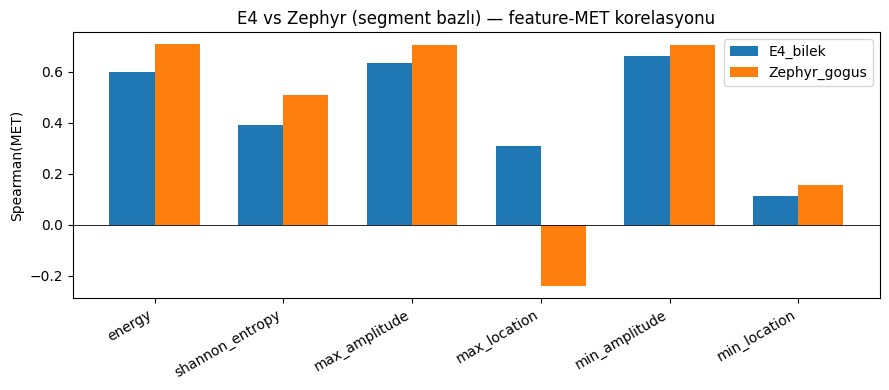

In [ ]:
fig,ax=plt.subplots(figsize=(9,4)); x=np.arange(len(FEATURE_NAMES)); w=0.35
for i,(n,d) in enumerate(PAIR.items()):
    sp=sp_map(seglev(d))
    ax.bar(x+(i-0.5)*w,[sp[c] for c in FEATURE_NAMES],w,label=n)
ax.set_xticks(x); ax.set_xticklabels(FEATURE_NAMES,rotation=30,ha='right'); ax.axhline(0,color='k',lw=.6)
ax.set_ylabel('Spearman(MET)'); ax.set_title('E4 vs Zephyr (segment bazlı) — feature-MET korelasyonu'); ax.legend()
plt.tight_layout(); plt.show()

## Muse (kafa)
Muse'un acc.csv dosyası: başlıksız, kolonlar zaman(unix), x, y, z; değerler zaten g. Zaman damgaları düzensiz olduğu için önce sıralıyorum, örnekleme hızını veriden hesaplıyorum (~44 Hz). Filtre 0.5–12 Hz. P02'de Muse verisi yok, o atlanıyor.

### Muse feature tablosu

In [ ]:
mdf,qcm=build_table('MUSE')
print("tablo:",mdf.shape,"| özne:",mdf['subject'].nunique())
mdf.to_csv('weee_muse_features.csv',index=False)
print(qcm[qcm['status']!='ok'].to_string(index=False) if (qcm['status']!='ok').any() else "sorunlu segment yok")

tablo: (12130, 9) | özne: 16
subject activity         status  n_windows
    P04   Cycle1     kapsamıyor          0
    P04   Cycle2     kapsamıyor          0
    P04     Run1     kapsamıyor          0
    P04     Run2     kapsamıyor          0
    P06     Run1     kapsamıyor          0
    P06     Run2     kapsamıyor          0
    P10      Sit     kapsamıyor          0
    P10    Stand     kapsamıyor          0
    P14    Stand geçersiz zaman          0
    P14   Cycle1 geçersiz zaman          0
    P14   Cycle2 geçersiz zaman          0
    P14     Run1 geçersiz zaman          0
    P14     Run2     kapsamıyor          0


### P01 Muse aktivite bazında sinyal

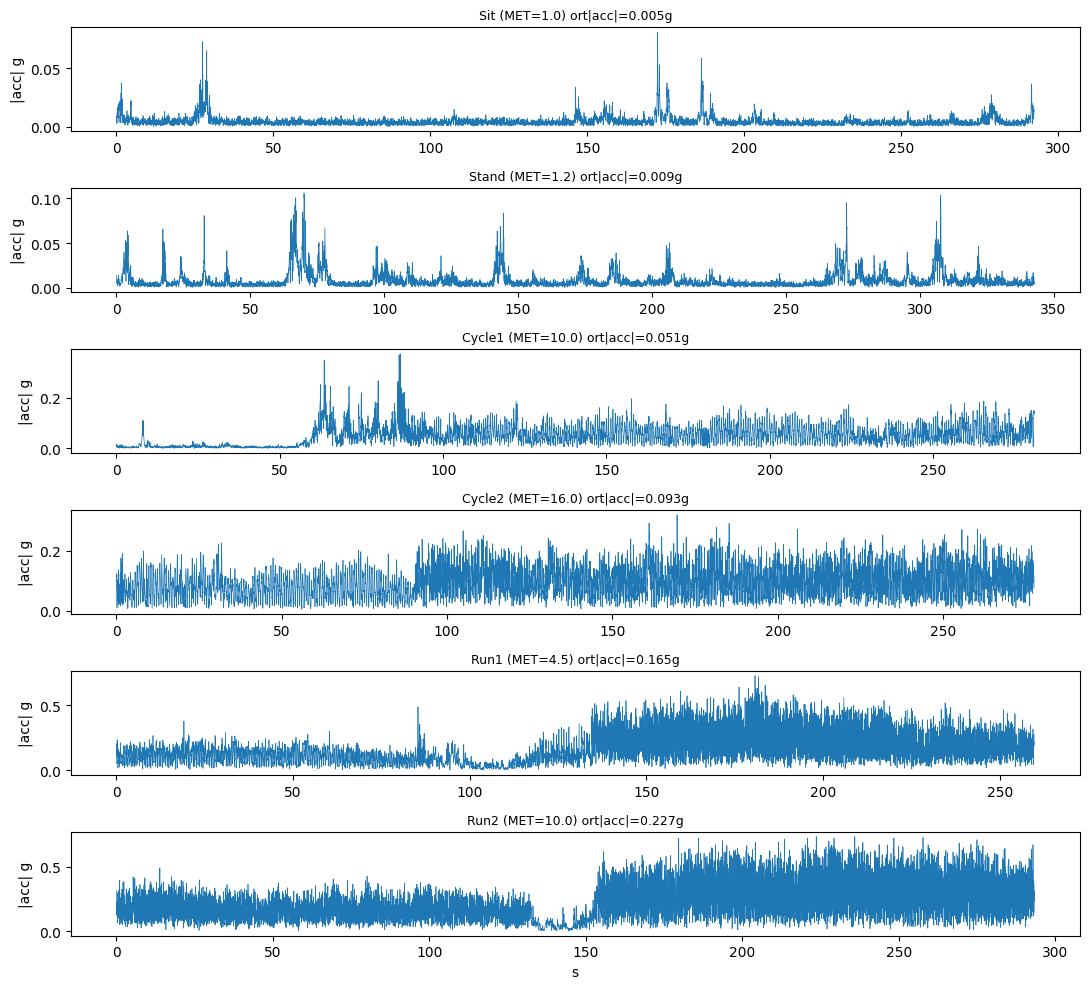

In [ ]:
mx,my,mz,mfs,mtt=load_device(glob.glob(os.path.join(DATA_ROOT,'P01','MUSE','acc.csv'))[0],'MUSE')
mmbp=mag3(bandpass(mx,mfs,0.5,12),bandpass(my,mfs,0.5,12),bandpass(mz,mfs,0.5,12))
fig,axs=plt.subplots(len(seg0),1,figsize=(11,10))
for ax,s in zip(axs,seg0):
    m=(mtt>=s['start'])&(mtt<s['end']); sig=mmbp[m]
    ax.plot(np.arange(len(sig))/mfs,sig,lw=0.5)
    ax.set_title(f"{s['activity']} (MET={s['MET']}) ort|acc|={sig.mean():.3f}g",fontsize=9); ax.set_ylabel('|acc| g')
axs[-1].set_xlabel('s'); plt.tight_layout(); plt.show()

### Muse feature ↔ MET korelasyonu

In [ ]:
corr_m=corr_table(mdf,FEATURE_NAMES); print(corr_m.to_string(index=False))

        feature  pearson  spearman p_spearman sig
         energy    0.469     0.734    0.0e+00 ***
  min_amplitude    0.572     0.728    0.0e+00 ***
  max_amplitude    0.617     0.719    0.0e+00 ***
shannon_entropy    0.362     0.386    0.0e+00 ***
   max_location    0.015     0.013    1.5e-01    
   min_location   -0.011    -0.012    1.8e-01    


## Karşılaştırma: E4 (bilek) vs Zephyr (göğüs) vs Muse (kafa)
Aynı 6 feature, aynı pipeline. Hangi konum MET'i daha iyi yakalıyor.

### Karşılaştırma tablosu (window ve segment bazlı)

In [ ]:
DEVS={'E4_bilek':df,'Zephyr_gogus':zdf,'Muse_kafa':mdf}
def sp_map(d): return {c:round(spearmanr(d[c],d['MET'])[0],3) for c in FEATURE_NAMES}
def seglev(d): return d.groupby(['subject','activity']).agg({**{c:'mean' for c in FEATURE_NAMES},'MET':'first'}).reset_index()

comp_win=pd.DataFrame({n:sp_map(d) for n,d in DEVS.items()}); comp_win.index.name='feature'
print("=== window-level Spearman(MET) ==="); print(comp_win.to_string())
comp_seg=pd.DataFrame({n:sp_map(seglev(d)) for n,d in DEVS.items()}); comp_seg.index.name='feature'
print("\n=== segment-level Spearman(MET) ==="); print(comp_seg.to_string())
comp_seg.to_csv('e4_zephyr_muse.csv')

=== window-level Spearman(MET) ===
                 E4_bilek  Zephyr_gogus  Muse_kafa
feature                                           
energy              0.628         0.686      0.734
shannon_entropy     0.158         0.297      0.386
max_amplitude       0.614         0.678      0.719
max_location        0.019        -0.013      0.013
min_amplitude       0.637         0.667      0.728
min_location        0.006         0.008     -0.012

=== segment-level Spearman(MET) ===
                 E4_bilek  Zephyr_gogus  Muse_kafa
feature                                           
energy              0.599         0.708      0.738
shannon_entropy     0.393         0.510      0.642
max_amplitude       0.634         0.706      0.729
max_location        0.310        -0.239      0.113
min_amplitude       0.664         0.707      0.747
min_location        0.112         0.155     -0.170


### Karşılaştırma grafiği

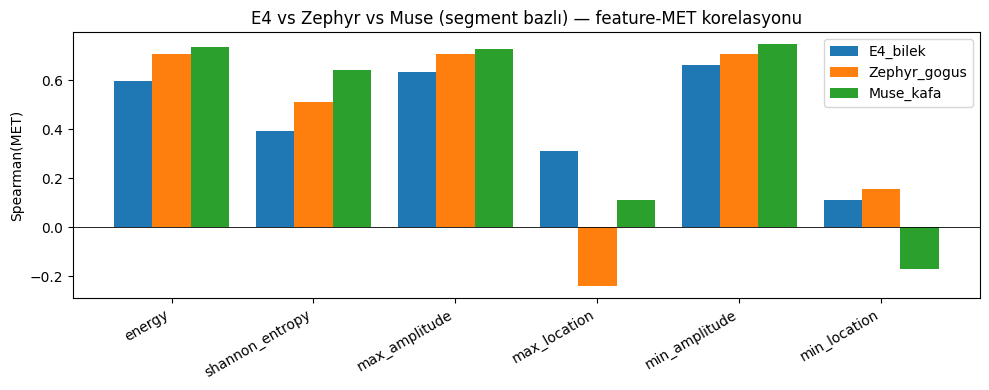

In [ ]:
fig,ax=plt.subplots(figsize=(10,4)); x=np.arange(len(FEATURE_NAMES)); w=0.27
for i,(n,d) in enumerate(DEVS.items()):
    sp=sp_map(seglev(d))
    ax.bar(x+(i-1)*w,[sp[c] for c in FEATURE_NAMES],w,label=n)
ax.set_xticks(x); ax.set_xticklabels(FEATURE_NAMES,rotation=30,ha='right'); ax.axhline(0,color='k',lw=.6)
ax.set_ylabel('Spearman(MET)'); ax.set_title('E4 vs Zephyr vs Muse (segment bazlı) — feature-MET korelasyonu'); ax.legend()
plt.tight_layout(); plt.show()

### Aktivite bazında ortalama energy (bisiklet farkı)

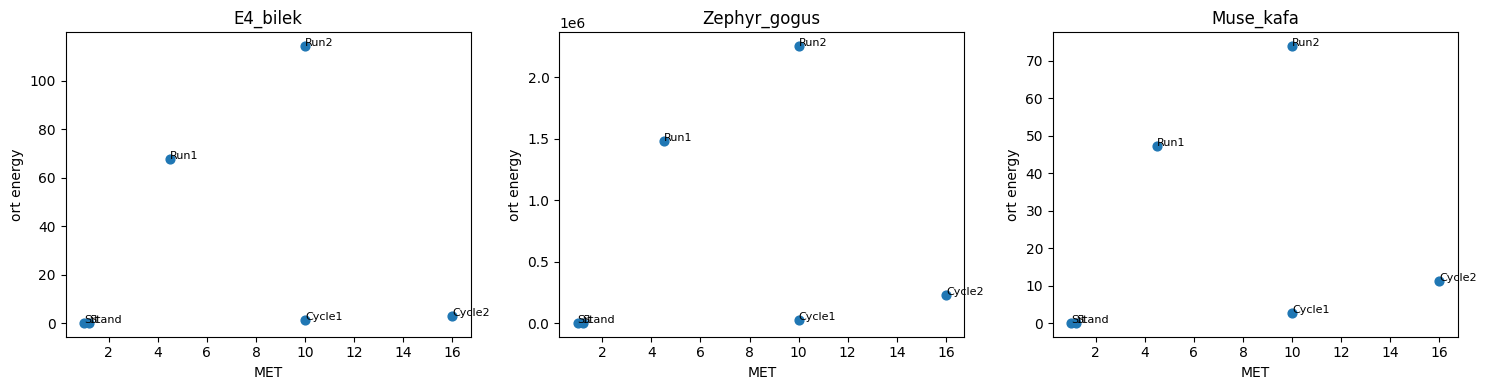

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a,(n,d) in zip(ax,DEVS.items()):
    g=d.groupby('activity').agg(MET=('MET','first'),f=('energy','mean')).reset_index()
    a.scatter(g['MET'],g['f'],s=40)
    for _,rr in g.iterrows(): a.annotate(rr['activity'],(rr['MET'],rr['f']),fontsize=8)
    a.set_xlabel('MET'); a.set_ylabel('ort energy'); a.set_title(n)
plt.tight_layout(); plt.show()

## Adil karşılaştırma (ortak segmentler)
Üç cihazın veri eksikleri farklı (Muse'da P02/P04/P06 kısmen yok). Yukarıdaki karşılaştırma her cihazı kendi mevcut verisiyle yapıyor, tam eşit değil. Burada **üç cihazda da geçerli olan** aynı (özne, aktivite) segmentlerini alıp öyle karşılaştırıyorum — aynı veri üzerinde.

In [ ]:
def ok_pairs(qc): return set(map(tuple, qc[qc['status']=='ok'][['subject','activity']].values))
common = ok_pairs(qc4) & ok_pairs(qcz) & ok_pairs(qcm)
print("üç cihazda da geçerli (özne,aktivite) sayısı:", len(common))

def filt(d):
    key=list(zip(d['subject'],d['activity']))
    return d[[k in common for k in key]].reset_index(drop=True)

DEVS_FAIR={'E4_bilek':filt(df),'Zephyr_gogus':filt(zdf),'Muse_kafa':filt(mdf)}
for n,d in DEVS_FAIR.items(): print(f"  {n}: {d.shape[0]} pencere, {d['subject'].nunique()} özne")

comp_win_f=pd.DataFrame({n:sp_map(d) for n,d in DEVS_FAIR.items()}); comp_win_f.index.name='feature'
print("\n=== window-level Spearman(MET) — ortak segmentler ==="); print(comp_win_f.to_string())
comp_seg_f=pd.DataFrame({n:sp_map(seglev(d)) for n,d in DEVS_FAIR.items()}); comp_seg_f.index.name='feature'
print("\n=== segment-level Spearman(MET) — ortak segmentler ==="); print(comp_seg_f.to_string())
comp_seg_f.to_csv('e4_zephyr_muse_fair.csv')

üç cihazda da geçerli (özne,aktivite) sayısı: 83
  E4_bilek: 12152 pencere, 16 özne
  Zephyr_gogus: 12144 pencere, 16 özne
  Muse_kafa: 12130 pencere, 16 özne

=== window-level Spearman(MET) — ortak segmentler ===
                 E4_bilek  Zephyr_gogus  Muse_kafa
feature                                           
energy              0.654         0.708      0.734
shannon_entropy     0.182         0.314      0.386
max_amplitude       0.642         0.701      0.719
max_location        0.020        -0.010      0.013
min_amplitude       0.664         0.695      0.728
min_location        0.007         0.008     -0.012

=== segment-level Spearman(MET) — ortak segmentler ===
                 E4_bilek  Zephyr_gogus  Muse_kafa
feature                                           
energy              0.623         0.735      0.738
shannon_entropy     0.435         0.522      0.642
max_amplitude       0.661         0.734      0.729
max_location        0.319        -0.187      0.113
min_amplitude   

### Adil karşılaştırma grafiği

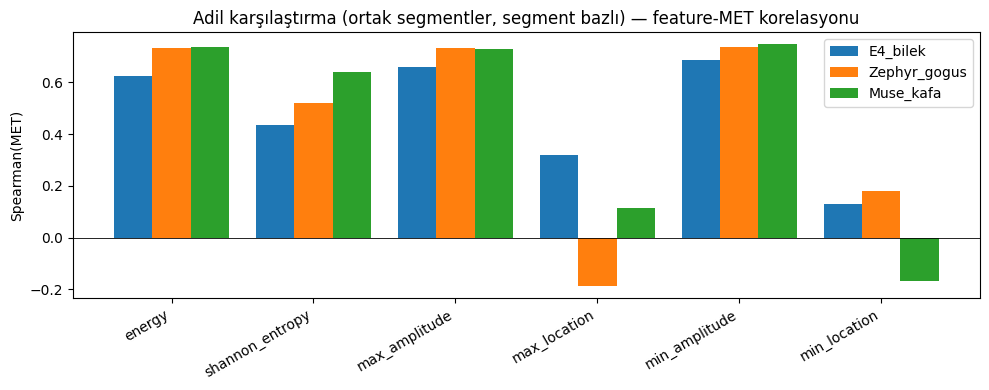

In [ ]:
fig,ax=plt.subplots(figsize=(10,4)); x=np.arange(len(FEATURE_NAMES)); w=0.27
for i,(n,d) in enumerate(DEVS_FAIR.items()):
    sp=sp_map(seglev(d))
    ax.bar(x+(i-1)*w,[sp[c] for c in FEATURE_NAMES],w,label=n)
ax.set_xticks(x); ax.set_xticklabels(FEATURE_NAMES,rotation=30,ha='right'); ax.axhline(0,color='k',lw=.6)
ax.set_ylabel('Spearman(MET)'); ax.set_title('Adil karşılaştırma (ortak segmentler, segment bazlı) — feature-MET korelasyonu'); ax.legend()
plt.tight_layout(); plt.show()